# Part C – Baseline Classification Model

Logistic Regression, evaluation metrics, confusion matrix, Type-I and Type-II errors.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv')
df.head()


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [2]:
from sklearn.preprocessing import LabelEncoder

date_cols = [c for c in df.columns if 'date' in c.lower()]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    df[col+'_year'] = df[col].dt.year
    df[col+'_month'] = df[col].dt.month
    df[col+'_day'] = df[col].dt.day
    df.drop(columns=[col], inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

target = 'risk_status'

X = df.drop(columns=[target])
y = df[target]


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = KNNImputer(n_neighbors=5)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Confusion Matrix
[[805   4]
 [  7 104]]

Accuracy : 0.9880434782608696
Precision: 0.9629629629629629
Recall   : 0.9369369369369369
F1 Score : 0.9497716894977168

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       809
           1       0.96      0.94      0.95       111

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



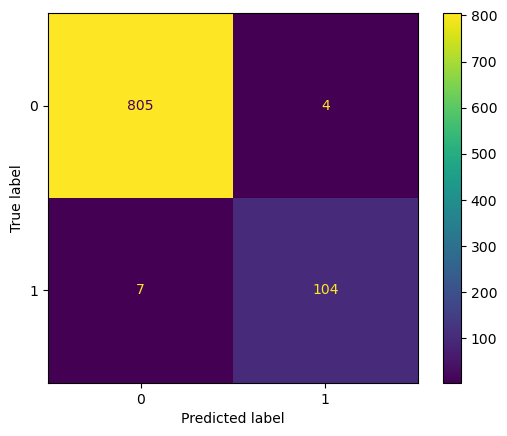

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()


In [7]:
TN, FP, FN, TP = cm.ravel()

print("TN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)

print("\nType-I Error (False Positive) =", FP)
print("Type-II Error (False Negative) =", FN)


TN = 805
FP = 4
FN = 7
TP = 104

Type-I Error (False Positive) = 4
Type-II Error (False Negative) = 7


## Report Interpretation

- Type-I Error = False Positive (Low Risk predicted as High Risk)
- Type-II Error = False Negative (High Risk predicted as Low Risk)
- In risk prediction, minimizing False Negatives is usually more important because risky customers may be missed.
